# Early Warning Prediction

This notebook uses the final XGBoost model to generate early warning predictions for future air quality deterioration.

The trained model produces a probability of deterioration for each observation. These probabilities are then converted into early warning signals using a selected decision threshold.

The analysis focuses on evaluating the model as an early warning system rather than training a new model.


## 1. Load Final Model

In [1]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt


In [2]:
MODEL_PATH = Path("../models/xgboost_final.joblib")

final_xgb = joblib.load(MODEL_PATH)

print("Final XGBoost model loaded successfully.")
print(f"Model path: {MODEL_PATH}")

Final XGBoost model loaded successfully.
Model path: ..\models\xgboost_final.joblib


### Model Fitting Verification

The loaded XGBoost model is checked to confirm that the estimator was fitted successfully before generating early warning predictions.


In [3]:
is_fitted = hasattr(
    final_xgb.named_steps["model"],
    "n_features_in_"
)

print(f"XGBoost fitted: {is_fitted}")

XGBoost fitted: True


## 2. Prepare Test Data

The unseen test set used for final model evaluation is prepared for early warning prediction.

The test period covers January 2016 to February 2017 and was not used during model training or hyperparameter tuning.

The same test period is retained to ensure consistency with the final model evaluation.


In [4]:
DATA_PATH = Path("../data/processed/airshift_labeled.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["datetime"]
)

TEST_START = "2016-01-01"
TEST_END = "2017-02-28 17:00:00"

test_data = df[
    (df["datetime"] >= TEST_START) &
    (df["datetime"] <= TEST_END)
].copy()

print("Test data shape:", test_data.shape)
print("Test date range:")
print(test_data["datetime"].min())
print(test_data["datetime"].max())

Test data shape: (121900, 100)
Test date range:
2016-01-01 00:00:00
2017-02-28 17:00:00


## 3. Define Prediction Features

The target variable is separated from the input features before generating early warning predictions.

The `Deterioration` column is retained as the actual outcome for evaluating the generated warnings, while `No` and `datetime` are excluded because they were not used as model features during training.


In [5]:
TARGET = "Deterioration"

EXCLUDE_COLUMNS = [
    TARGET,
    "No",
    "datetime"
]

X_test = test_data.drop(columns=EXCLUDE_COLUMNS)
y_test = test_data[TARGET]

print("Test features shape:", X_test.shape)
print("Test target shape:", y_test.shape)
print("Number of features:", X_test.shape[1])

Test features shape: (121900, 97)
Test target shape: (121900,)
Number of features: 97


## 4. Generate Deterioration Probabilities

The final XGBoost model is used to generate the predicted probability of future air quality deterioration for each observation in the unseen test set.

The probability for the positive class (`Deterioration = 1`) is retained for subsequent conversion into early warning signals using a decision threshold.


In [6]:
y_test_prob = final_xgb.predict_proba(X_test)[:, 1]

print("Predicted probabilities generated successfully.")
print("Number of predictions:", len(y_test_prob))
print("Minimum probability:", y_test_prob.min())
print("Maximum probability:", y_test_prob.max())
print("Mean probability:", y_test_prob.mean())

Predicted probabilities generated successfully.
Number of predictions: 121900
Minimum probability: 0.0004506121
Maximum probability: 0.9995968
Mean probability: 0.4957185


## 5. Warning Threshold

The predicted deterioration probabilities are converted into early warning signals using a decision threshold.

An observation is classified as an early warning when its predicted probability is equal to or greater than the selected threshold.

Because the system is designed for early warning, the threshold should be evaluated based on the trade-off between detecting deterioration events and generating false alarms.


In [7]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = []

for threshold in thresholds:
    y_warning = (y_test_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_warning)
    recall = recall_score(y_test, y_warning)
    f1 = f1_score(y_test, y_warning)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_warning
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.30,0.625185,0.899818,0.737772,31652,5878
1,0.35,0.649035,0.865372,0.741751,27456,7899
2,0.40,0.673316,0.825542,0.741699,23501,10236
3,0.45,0.699033,0.781467,0.737955,19741,12822
4,0.50,0.724362,0.731461,0.727894,16331,15756
5,0.55,0.750531,0.680125,0.713596,13264,18768
6,0.60,0.776531,0.625177,0.692682,10556,21992
7,0.65,0.804246,0.568166,0.665901,8114,25337
8,0.70,0.831526,0.506996,0.629919,6027,28926


In [8]:
MODEL_DIR = Path("../models")

print("Saved model files:")
for file in MODEL_DIR.iterdir():
    print("-", file.name)

Saved model files:
- xgboost_final.joblib


In [9]:
TRAIN_END = "2014-12-31 23:00:00"
VALIDATION_START = "2015-01-01"
VALIDATION_END = "2015-12-31 23:00:00"

development_data = df[
    df["datetime"] <= TRAIN_END
].copy()

validation_data = df[
    (df["datetime"] >= VALIDATION_START) &
    (df["datetime"] <= VALIDATION_END)
].copy()

print("Development data shape:", development_data.shape)
print("Development date range:")
print(development_data["datetime"].min())
print(development_data["datetime"].max())

print("\nValidation data shape:", validation_data.shape)
print("Validation date range:")
print(validation_data["datetime"].min())
print(validation_data["datetime"].max())

Development data shape: (191665, 100)
Development date range:
2013-03-01 00:00:00
2014-12-31 23:00:00

Validation data shape: (104816, 100)
Validation date range:
2015-01-01 00:00:00
2015-12-31 23:00:00


### 1. Prepare Features and Target

The target variable is separated from the input features for the development and validation periods.

The same feature exclusions used during model development are applied to maintain consistency with the final XGBoost model.


In [10]:
TARGET = "Deterioration"

EXCLUDE_COLUMNS = [
    TARGET,
    "No",
    "datetime"
]

X_development = development_data.drop(columns=EXCLUDE_COLUMNS)
y_development = development_data[TARGET]

X_validation = validation_data.drop(columns=EXCLUDE_COLUMNS)
y_validation = validation_data[TARGET]

print("Development features shape:", X_development.shape)
print("Development target shape:", y_development.shape)

print("\nValidation features shape:", X_validation.shape)
print("Validation target shape:", y_validation.shape)

Development features shape: (191665, 97)
Development target shape: (191665,)

Validation features shape: (104816, 97)
Validation target shape: (104816,)


### 5.2 Train Threshold Selection Model

A separate XGBoost model is fitted using only the 2013–2014 development period.

The model uses the same tuned hyperparameters selected during model development. The 2015 validation period is then used exclusively to evaluate different warning thresholds.

This prevents the final test set from influencing the threshold selection process.


In [11]:
print("Final model pipeline steps:")
print(final_xgb.named_steps.keys())

print("\nPreprocessor:")
print(final_xgb.named_steps["preprocessor"])

Final model pipeline steps:
dict_keys(['preprocessor', 'model'])

Preprocessor:
ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['wd', 'station']),
                                ('numerical', SimpleImputer(strategy='median'),
                                 ['year', 'month', 'day', 'hour', 'PM2.5',
                                  'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP',
                                  'PRES', 'DEWP', 'RAIN', 'WSPM', 'day_of_week',
                                  'is_weekend', 'PM2.5_lag_1h', 'PM2.5_lag_3h',
                                  'PM2.5_lag_6h', 'PM10_lag_1h', 'PM10_lag_3h',
                                  'PM10_

In [12]:

threshold_preprocessor = clone(
    final_xgb.named_steps["preprocessor"]
)

threshold_model = Pipeline(
    steps=[
        ("preprocessor", threshold_preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=400,
                learning_rate=0.1,
                max_depth=6,
                min_child_weight=3,
                subsample=0.7,
                colsample_bytree=1.0,
                random_state=42,
                n_jobs=2,
                eval_metric="logloss"
            )
        )
    ]
)

print("Starting threshold-selection model training...")
print("Development data:", X_development.shape)

threshold_model.fit(
    X_development,
    y_development
)

print("Threshold-selection model training completed successfully.")

Starting threshold-selection model training...
Development data: (191665, 97)
Threshold-selection model training completed successfully.


### 5.3 Generate Validation Probabilities

The threshold-selection model is used to generate deterioration probabilities for the unseen 2015 validation period.

These probabilities will be used to evaluate different warning thresholds before the selected threshold is applied to the final test period.


In [13]:
y_validation_prob = threshold_model.predict_proba(
    X_validation
)[:, 1]

print("Validation probabilities generated successfully.")
print("Number of predictions:", len(y_validation_prob))
print("Minimum probability:", y_validation_prob.min())
print("Maximum probability:", y_validation_prob.max())
print("Mean probability:", y_validation_prob.mean())

Validation probabilities generated successfully.
Number of predictions: 104816
Minimum probability: 9.9503086e-05
Maximum probability: 0.9992524
Mean probability: 0.48155317


### 5.4 Select Warning Threshold

Different decision thresholds are evaluated on the 2015 validation period to examine the trade-off between precision and recall.

The validation period is used only for selecting the operating threshold. The final test period remains untouched until the selected threshold is applied to the final XGBoost model.


In [14]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

validation_threshold_results = []

for threshold in thresholds:
    y_warning = (y_validation_prob >= threshold).astype(int)

    precision = precision_score(y_validation, y_warning)
    recall = recall_score(y_validation, y_warning)
    f1 = f1_score(y_validation, y_warning)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        y_warning
    ).ravel()

    validation_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positives": fp,
        "False Negatives": fn
    })

validation_threshold_results_df = pd.DataFrame(
    validation_threshold_results
)

validation_threshold_results_df

,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.30,0.620139,0.881260,0.727993,26795,5894
1,0.35,0.642142,0.845219,0.729817,23381,7683
2,0.40,0.664963,0.804565,0.728133,20122,9701
3,0.45,0.687440,0.760244,0.722011,17158,11901
4,0.50,0.711215,0.710585,0.710900,14322,14366
5,0.55,0.736852,0.659616,0.696098,11693,16896
6,0.60,0.761737,0.604073,0.673805,9379,19653
7,0.65,0.788024,0.547464,0.646078,7310,22463
8,0.70,0.816885,0.488094,0.611070,5431,25410


### 5.5 Selected Warning Threshold

A threshold of **0.30** is selected for the early warning system based on the 2015 validation results.

The threshold is chosen with emphasis on **recall**, since missing an actual deterioration event is particularly important in an early warning context.

At this threshold, the validation results are:

* Precision: **0.6201**
* Recall: **0.8813**
* F1-score: **0.7280**
* False negatives: **5,894**

The selected threshold is determined using the validation period only. The final test period remains unseen and is used afterward to evaluate the complete early warning system.


## 6. Final Early Warning Performance

The selected warning threshold of **0.30** is applied to the deterioration probabilities generated by the final XGBoost model on the unseen 2016–2017 test period.

This provides the final performance evaluation of the AirShift early warning system. The test set is used only at this stage and was not used to select the model or warning threshold.


In [15]:
WARNING_THRESHOLD = 0.30

y_warning = (
    y_test_prob >= WARNING_THRESHOLD
).astype(int)

precision = precision_score(y_test, y_warning)
recall = recall_score(y_test, y_warning)
f1 = f1_score(y_test, y_warning)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_warning
).ravel()

print("Final Early Warning Performance")
print("-" * 40)
print(f"Warning threshold: {WARNING_THRESHOLD:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

Final Early Warning Performance
----------------------------------------
Warning threshold: 0.30
Precision: 0.6252
Recall: 0.8998
F1-score: 0.7378
True Negatives: 31575
False Positives: 31652
False Negatives: 5878
True Positives: 52795


## 7. Analyze Warning Examples

The generated warning signals are examined to understand how the early warning system behaves around deterioration events.

The analysis focuses on the timing of warnings relative to observed deterioration events and helps assess whether the model provides useful advance warning rather than only identifying deterioration at or after its occurrence.


### 7.1 Identify Warning Signals

The warning signals generated on the final test set are identified using the selected probability threshold of **0.30**.

Each warning is linked to its corresponding deterioration outcome so that the timing of successful warnings can be examined in the following steps.


In [16]:
warning_data = test_data[
    ["datetime", "Deterioration"]
].copy()

warning_data["Deterioration_Probability"] = y_test_prob

warning_data["Warning"] = (
    warning_data["Deterioration_Probability"] >= WARNING_THRESHOLD
).astype(int)

print("Warning signals generated successfully.")
print("Total observations:", len(warning_data))
print("Warning signals:", warning_data["Warning"].sum())
print("No warning:", (warning_data["Warning"] == 0).sum())

Warning signals generated successfully.
Total observations: 121900
Warning signals: 84447
No warning: 37453


### 7.2 Identify Deterioration Events

The deterioration target indicates whether a significant PM2.5 increase is expected within the following six hours.

Because consecutive observations may belong to the same deterioration episode, consecutive positive labels are treated as part of the same event sequence when analyzing warning timing.


In [17]:
event_data = warning_data.copy()

event_data["New_Event"] = (
    (event_data["Deterioration"] == 1) &
    (
        (event_data["Deterioration"].shift(1).fillna(0) == 0)
    )
).astype(int)

print("Deterioration observations:", event_data["Deterioration"].sum())
print("Detected event starts:", event_data["New_Event"].sum())

Deterioration observations: 58673.0
Detected event starts: 12100


### 7.3 Determine Deterioration Occurrence Time

For each positive deterioration label, the actual deterioration occurrence time is identified as the earliest future hour within the six-hour horizon at which PM2.5 reaches at least 30% above its value at the prediction time.

This allows warning lead time to be measured relative to the estimated occurrence of the deterioration event rather than the prediction timestamp itself.


In [18]:
print("Station column available:", "station" in test_data.columns)
print("Number of stations:", test_data["station"].nunique())
print("Datetime sorted:", test_data["datetime"].is_monotonic_increasing)
print("Unique station names:", test_data["station"].unique())

Station column available: True
Number of stations: 12
Datetime sorted: False
Unique station names: <StringArray>
[ 'Aotizhongxin',     'Changping',      'Dingling',        'Dongsi',
      'Guanyuan',       'Gucheng',       'Huairou',  'Nongzhanguan',
        'Shunyi',       'Tiantan',        'Wanliu', 'Wanshouxigong']
Length: 12, dtype: str


### 7.4 Prepare Station-Level Temporal Data

The test data contains observations from 12 monitoring stations, so temporal operations must be performed separately within each station.

The data is sorted by station and datetime before identifying future deterioration conditions. This prevents observations from different stations from being incorrectly treated as consecutive time points.


In [19]:
temporal_data = test_data.copy()

temporal_data = temporal_data.sort_values(
    ["station", "datetime"]
).reset_index(drop=True)

print("Temporal data sorted successfully.")
print("Datetime sorted within stations:",
      temporal_data.groupby("station")["datetime"]
      .apply(lambda x: x.is_monotonic_increasing)
      .all())

print("Number of rows:", len(temporal_data))
print("Number of stations:", temporal_data["station"].nunique())

Temporal data sorted successfully.
Datetime sorted within stations: True
Number of rows: 121900
Number of stations: 12


### 7.5 Determine Deterioration Occurrence Time

For each observation, the actual deterioration occurrence time is identified by examining the following six hours within the same monitoring station.

The first future hour at which PM2.5 reaches at least 30% above the current PM2.5 value is treated as the estimated deterioration occurrence time.

This follows the same definition used to create the `Deterioration` target and allows warning lead time to be measured against the estimated occurrence of deterioration.


In [20]:
temporal_data["Occurrence_Time"] = pd.NaT

for h in range(1, 7):
    future_pm25 = (
        temporal_data
        .groupby("station")["PM2.5"]
        .shift(-h)
    )

    condition = (
        temporal_data["Occurrence_Time"].isna()
        & temporal_data["PM2.5"].notna()
        & future_pm25.notna()
        & (future_pm25 >= temporal_data["PM2.5"] * 1.30)
    )

    temporal_data.loc[condition, "Occurrence_Time"] = (
        temporal_data.loc[condition, "datetime"]
        + pd.Timedelta(hours=h)
    )

print("Deterioration occurrence times identified.")

positive_labels = temporal_data["Deterioration"] == 1

print(
    "Positive labels:",
    positive_labels.sum()
)

print(
    "Positive labels with occurrence time:",
    temporal_data.loc[
        positive_labels, "Occurrence_Time"
    ].notna().sum()
)

print(
    "Positive labels without occurrence time:",
    temporal_data.loc[
        positive_labels, "Occurrence_Time"
    ].isna().sum()
)

Deterioration occurrence times identified.
Positive labels: 58673
Positive labels with occurrence time: 58650
Positive labels without occurrence time: 23


### 7.6 Calculate Warning Lead Time

Warning lead time is calculated as the time between the warning timestamp and the estimated deterioration occurrence time.

Only observations with a warning and a valid deterioration occurrence time are included in this calculation.

A positive lead time indicates that the warning was generated before the estimated deterioration occurrence.


In [21]:
# Create warning data with station and datetime
warning_by_time = test_data[
    ["station", "datetime"]
].copy()

warning_by_time["Warning"] = y_warning

# Add warning signals to the station-sorted temporal data
temporal_data = temporal_data.merge(
    warning_by_time,
    on=["station", "datetime"],
    how="left",
    validate="one_to_one"
)

successful_warnings = temporal_data[
    (temporal_data["Warning"] == 1) &
    (temporal_data["Occurrence_Time"].notna())
].copy()

successful_warnings["Lead_Time_Hours"] = (
    successful_warnings["Occurrence_Time"]
    - successful_warnings["datetime"]
).dt.total_seconds() / 3600

print("Successful warnings:", len(successful_warnings))

print(
    "Lead time range:",
    successful_warnings["Lead_Time_Hours"].min(),
    "to",
    successful_warnings["Lead_Time_Hours"].max(),
    "hours"
)

print(
    "Mean lead time:",
    successful_warnings["Lead_Time_Hours"].mean()
)

print(
    "Median lead time:",
    successful_warnings["Lead_Time_Hours"].median()
)

Successful warnings: 52786
Lead time range: 1.0 to 6.0 hours
Mean lead time: 2.736426325161975
Median lead time: 2.0


### 7.7 Lead Time Distribution

The distribution of warning lead times is examined to understand how far in advance the system identifies deterioration events.

Lead times are grouped by the number of hours between the warning timestamp and the estimated deterioration occurrence time.

This provides a more detailed view of the timing of successful warnings within the six-hour prediction horizon.


In [22]:
lead_time_distribution = (
    successful_warnings["Lead_Time_Hours"]
    .value_counts()
    .sort_index()
)

print("Lead Time Distribution")
print("-" * 30)

for hours, count in lead_time_distribution.items():
    percentage = (
        count / len(successful_warnings)
    ) * 100

    print(
        f"{int(hours)} hour(s): "
        f"{count:,} warnings "
        f"({percentage:.2f}%)"
    )

print()
print(
    "Total successful warnings:",
    len(successful_warnings)
)

Lead Time Distribution
------------------------------
1 hour(s): 15,677 warnings (29.70%)
2 hour(s): 12,072 warnings (22.87%)
3 hour(s): 8,937 warnings (16.93%)
4 hour(s): 6,770 warnings (12.83%)
5 hour(s): 5,247 warnings (9.94%)
6 hour(s): 4,083 warnings (7.74%)

Total successful warnings: 52786


### 7.8 Validate Lead Time Calculation

The calculated lead times are validated to ensure that they are consistent with the six-hour deterioration prediction horizon.

The validation checks the range of lead times, confirms that all successful warnings occur before the estimated deterioration time, and verifies that no invalid or missing lead-time values are included.


In [23]:
lead_times = successful_warnings["Lead_Time_Hours"]

print("Lead Time Validation")
print("-" * 30)

print("Minimum lead time:", lead_times.min())
print("Maximum lead time:", lead_times.max())
print("Missing lead times:", lead_times.isna().sum())
print(
    "Non-positive lead times:",
    (lead_times <= 0).sum()
)
print(
    "Lead times beyond 6 hours:",
    (lead_times > 6).sum()
)

print()
print(
    "All lead times within 1–6 hours:",
    lead_times.between(1, 6).all()
)

Lead Time Validation
------------------------------
Minimum lead time: 1.0
Maximum lead time: 6.0
Missing lead times: 0
Non-positive lead times: 0
Lead times beyond 6 hours: 0

All lead times within 1–6 hours: True


### 7.9 Lead Time Visualization

The distribution of successful warning lead times is visualized to show how frequently the system identifies deterioration at different points within the six-hour prediction horizon.

The visualization reports the number of successful warnings associated with each lead-time value.


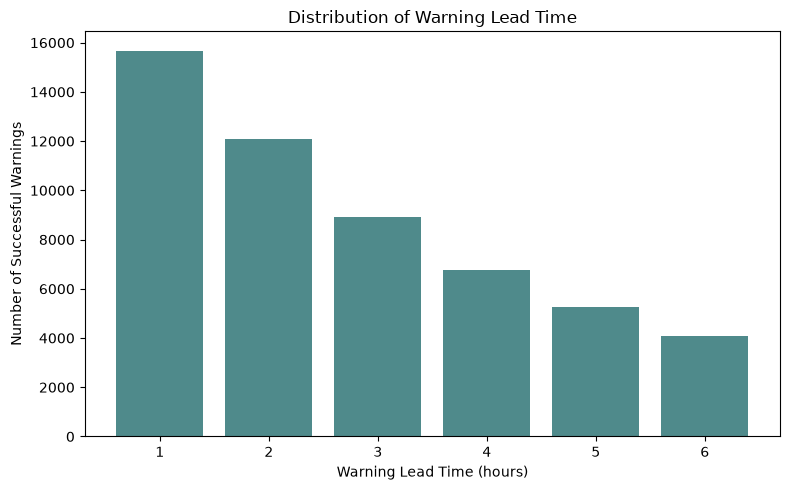

Figure saved to: ..\reports\figures\11_early_warning_prediction\07_lead_time_distribution.png


In [27]:
lead_time_counts = (
    successful_warnings["Lead_Time_Hours"]
    .value_counts()
    .sort_index()
)

# Create output directory if it does not exist
FIGURE_DIR = Path("../reports/figures/11_early_warning_prediction")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_PATH = (
    FIGURE_DIR /
    "07_lead_time_distribution.png"
)

plt.figure(figsize=(8, 5))

plt.bar(
    lead_time_counts.index.astype(int),
    lead_time_counts.values,
    color="#4F8A8B"
)

plt.xlabel("Warning Lead Time (hours)")
plt.ylabel("Number of Successful Warnings")
plt.title("Distribution of Warning Lead Time")

plt.xticks(range(1, 7))
plt.tight_layout()

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {FIGURE_PATH}")

### 7.10 Lead Time Summary

The warning lead-time results are summarized to quantify how frequently successful warnings occur at different points within the six-hour prediction horizon.


In [28]:
lead_time_summary = (
    successful_warnings["Lead_Time_Hours"]
    .value_counts()
    .sort_index()
    .rename_axis("Lead_Time_Hours")
    .reset_index(name="Warnings")
)

lead_time_summary["Percentage"] = (
    lead_time_summary["Warnings"]
    / len(successful_warnings)
    * 100
)

print(lead_time_summary.to_string(index=False))

print()
print(
    "Warnings with lead time >= 2 hours:",
    (successful_warnings["Lead_Time_Hours"] >= 2).sum()
)

print(
    "Percentage with lead time >= 2 hours:",
    (
        successful_warnings["Lead_Time_Hours"].ge(2).mean()
        * 100
    )
)

 Lead_Time_Hours  Warnings  Percentage
             1.0     15677   29.699163
             2.0     12072   22.869700
             3.0      8937   16.930626
             4.0      6770   12.825370
             5.0      5247    9.940136
             6.0      4083    7.735005

Warnings with lead time >= 2 hours: 37109
Percentage with lead time >= 2 hours: 70.30083734323495


## 8. Warning System Findings

The final early warning performance on the unseen test set is summarized below.

| Metric            |               Result |
| ----------------- | -------------------: |
| Warning threshold |             **0.30** |
| Precision         |           **0.6252** |
| Recall            |           **0.8998** |
| F1-score          |           **0.7378** |
| True positives    |           **52,795** |
| False negatives   |            **5,878** |
| Warning signals   | **84,447 / 121,900** |
| Lead time range   |        **1–6 hours** |
| Mean lead time    |       **2.74 hours** |
| Median lead time  |          **2 hours** |

The results indicate that the system identifies a large proportion of deterioration events while generating warnings at different points within the six-hour prediction horizon.

The lead-time results represent the timing of warnings relative to the **estimated deterioration occurrence** and should not be interpreted as a guaranteed operational warning time.
